# Test plot - DAG with labelled arrows

Simple way to label the edges on a DAG with the effect size.

## Code setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

## Generate nodes and edges for DAG

Make a dataframe where values are 0 when there is no edge and 1 when there is. The edge goes from the index label to the column label.

In [15]:
nodes = ['a', 'b', 'c', 'd', 'e', 'treatment', 'outcome']
df_effects = pd.DataFrame(columns=nodes, index=nodes, dtype=int).fillna(0)

df_effects

,a,b,c,d,e,treatment,outcome
a,0.0,0.0,0.0,0.0,0.0,0.0,0.0
b,0.0,0.0,0.0,0.0,0.0,0.0,0.0
c,0.0,0.0,0.0,0.0,0.0,0.0,0.0
d,0.0,0.0,0.0,0.0,0.0,0.0,0.0
e,0.0,0.0,0.0,0.0,0.0,0.0,0.0
treatment,0.0,0.0,0.0,0.0,0.0,0.0,0.0
outcome,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [2]:
nodes = ['a', 'b', 'c', 'd', 'e', 'treatment', 'outcome']
df_effects = pd.DataFrame(columns=nodes, index=nodes, dtype=int).fillna(0)
df_effects.loc['a', 'treatment'] = 1
df_effects.loc['a', 'outcome'] = 1
df_effects.loc['b', 'outcome'] = 1
df_effects.loc['d', 'treatment'] = 1
df_effects.loc['e', 'treatment'] = 1
df_effects.loc['e', 'outcome'] = 1
df_effects.loc['treatment', 'outcome'] = 1

In [3]:
df_effects

,a,b,c,d,e,treatment,outcome
a,0.0,0.0,0.0,0.0,0.0,1.0,1.0
b,0.0,0.0,0.0,0.0,0.0,0.0,1.0
c,0.0,0.0,0.0,0.0,0.0,0.0,0.0
d,0.0,0.0,0.0,0.0,0.0,1.0,0.0
e,0.0,0.0,0.0,0.0,0.0,1.0,1.0
treatment,0.0,0.0,0.0,0.0,0.0,0.0,1.0
outcome,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Create effect size for each edge:

In [4]:
effect_sizes = np.round(np.random.rand(*df_effects.values.shape) * df_effects.values, 4)
df_effect_sizes = pd.DataFrame(effect_sizes, columns=nodes, index=nodes)

In [5]:
df_effect_sizes

,a,b,c,d,e,treatment,outcome
a,0.0,0.0,0.0,0.0,0.0,0.8826,0.1608
b,0.0,0.0,0.0,0.0,0.0,0.0000,0.5819
c,0.0,0.0,0.0,0.0,0.0,0.0000,0.0000
d,0.0,0.0,0.0,0.0,0.0,0.0426,0.0000
e,0.0,0.0,0.0,0.0,0.0,0.4426,0.4689
treatment,0.0,0.0,0.0,0.0,0.0,0.0000,0.6679
outcome,0.0,0.0,0.0,0.0,0.0,0.0000,0.0000


Pass the data into networkx:

In [6]:
g = nx.DiGraph(df_effects)
edges = g.edges()

In [7]:
edges

OutEdgeView([('a', 'treatment'), ('a', 'outcome'), ('b', 'outcome'), ('d', 'treatment'), ('e', 'treatment'), ('e', 'outcome'), ('treatment', 'outcome')])

## Formatting for plot

Location of each node:

In [8]:
pos = {'a': [0, 2], 'b': [1, 2], 'c': [2, 2], 'd': [3, 2], 'e': [4, 2],
       'treatment': [2, 1], 'outcome': [2, 0]}

Make a dictionary for the edge labels. Each key is an edge (start, end) and each value is its label.

In [9]:
# Define label for each edge:
labels = []
for start_node, end_node in edges:
    # Pick out the value to annotate:
    edge_effect = df_effect_sizes.loc[start_node, end_node]
    label = f'{edge_effect:.2f}'  # show only 2 decimal places
    labels.append(label)
labels = dict(zip(edges, labels)) 

## Plot with labels

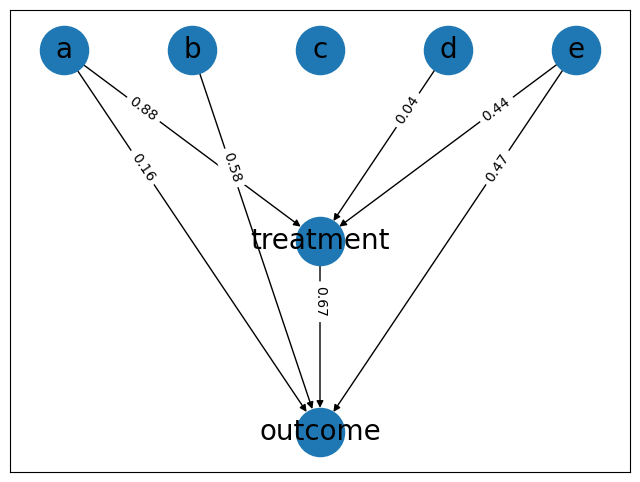

In [11]:
# Need to give node size to both nodes and edges functions:
node_size = 1200

# Draw DAG with networkx:
fig, ax = plt.subplots(figsize=(8, 6))

nx.draw_networkx_nodes(g, pos, node_size=node_size, ax=ax)
nx.draw_networkx_labels(g, pos, font_size=20, ax=ax)  # node labels

nx.draw_networkx_edges(
    g, pos,
    node_size=node_size,
    ax=ax
)

# To not interrupt the lines, use bbox=dict(alpha=0).
# To draw box around each edge label, use bbox=dict(fc='white', ec='black')
nx.draw_networkx_edge_labels(
    g,
    pos,
    labels,
    label_pos=0.3,  # how far along the line to draw the label
    ax=ax,
)

plt.show()

## Plot with curved edges and labels

Set up a function to decide how much each line should curve.

For each line, make a different curve depending on whether the end point is further left or right from the start point.

In [12]:
def make_connectionstyle_dict(edges, pos, rad=0.15):
    """
    Build a dictionary of arrow curves depending on x position.

    edges is a list of (start node, end node) for each edge.
    pos is a dictionary of (x, y) for each node.

    rad is the default curve.

    connectionstyle works with arc3 and angle3.
    """
    # Calculate a separate rad for each curve:
    rads = []
    for start_node, end_node in edges:
        # X coordinates of nodes:
        x_start = pos[start_node][0]
        x_end = pos[end_node][0]
        # Choose curve depending on whether start x is left or
        # right of end x:
        if x_start < x_end:
            r = rad
        elif x_start == x_end:
            r = 0.0
        else:
            r = -rad
        rads.append(r)
    # Turn these values into a dictionary so they can be matched to
    # each edge:
    dict_connectionstyle = dict(zip(edges, [f"arc3,rad={r}" for r in rads]))
    return dict_connectionstyle

In [13]:
dict_connectionstyle = make_connectionstyle_dict(edges, pos)

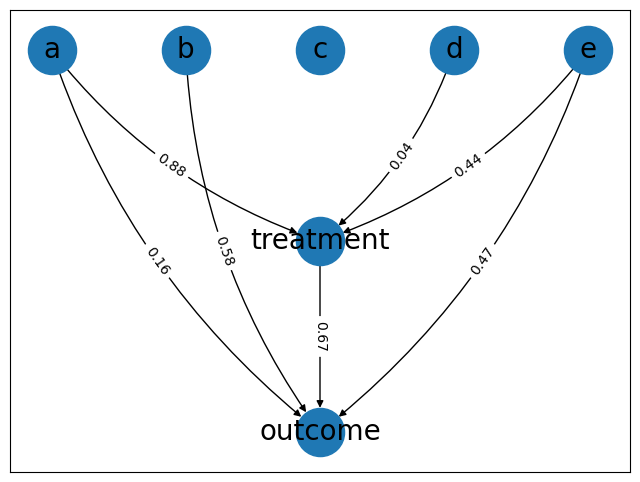

In [14]:
# Need to give node size to both nodes and edges functions:
node_size = 1200

# Draw DAG with networkx:
fig, ax = plt.subplots(figsize=(8, 6))

nx.draw_networkx_nodes(g, pos, node_size=node_size, ax=ax)
nx.draw_networkx_labels(g, pos, font_size=20, ax=ax)  # node labels

# Draw each edge and its label separately so that a different
# curve (connectionstyle) can be given each time:
for edge in edges:
    c = dict_connectionstyle[edge]
    edges_here = [edge]
    labels_here = {edge: labels[edge]}
    # Draw the specific edge/arrow
    nx.draw_networkx_edges(
        g, pos, edgelist=edges_here, connectionstyle=c, node_size=node_size,
    )
    # Draw the specific edge label matching the connectionstyle
    nx.draw_networkx_edge_labels(
        g, pos, labels_here, connectionstyle=c
    )

plt.show()